In [1]:
import os
os.environ['MPLCONFIGDIR'] = "/mnt/storage6/grace/plt_temp/"
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4 as nc
from netCDF4 import Dataset

import datetime
import cftime
import time

import gsw

In [99]:
def preprocess4(ds):
    ds = ds[['vosaline', 'votemper']]
    ds = ds.sel(x_grid_T = slice(150,375))
    ds = ds.sel(y_grid_T = slice(250,450))
    return ds

def preprocess12(ds):
    ds = ds[['vosaline', 'votemper', 'nav_lon', 'nav_lat']]
    ds = ds.sel(x = slice(450,1125))
    ds = ds.sel(y = slice(750,1350))
    ds = np.where(
    return ds
t_grid4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2018m05d25_gridT.nc", preprocess=preprocess4)
t_grid12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2018m05d25_gridT.nc")

s4 = gsw.SA_from_Sstar(t_grid4['vosaline'][:] * (35.16504/35), 10.1325, t_grid4.nav_lon_grid_T, t_grid4.nav_lat_grid_T)[0,:,:,:] #absolute salinity
s12 = gsw.SA_from_Sstar(t_grid12['vosaline'][:] * (35.16504/35), 10.1325, t12.nav_lon, t12.nav_lat) #absolute salinity

rho4 = gsw.sigma0(s4, t_grid4['votemper'][0,:,:,:])
rho12 = gsw.sigma0(s12, t12['votemper'][:])[0,:,:,:]

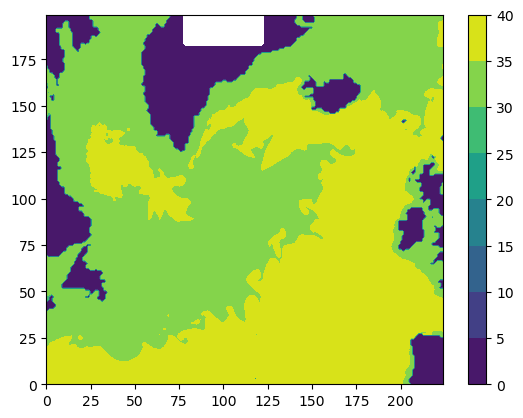

In [100]:
plt.contourf(s4[0,:,:])
plt.colorbar()

In [74]:
rho_goal = 27.8

resid4 = (rho4)
resid12 = rho12 - rho_goal

In [76]:
b = np.min(resid4, axis=0)

KeyboardInterrupt: 

In [65]:

np.min(resid4, axis=0)

low = np.zeros((200, 225))
high = np.zeros((200, 225))

for x in range(50):
    print(x)
    n = resid4[x,:,:]
    v = np.where(n == b)
    m = np.where(n[v] < 0) #under
    p = np.where(n[v] > 0) #over

    low[m] = x
    high[m] = x+1

    low[p] = x-1
    high[p] = x
    

0


IndexError: index 200 is out of bounds for axis 0 with size 200